# Lab 1: Gray Scale Image and Histogram Generation

## Theory

What is **histogram**? You can consider histogram as a graph or plot, which gives you an overall
idea about the intensity distribution of an image. It is a plot with pixel values (ranging from 0 to
255, not always) in X-axis and corresponding number of pixels in the image on Y-axis.

It is just another way of understanding the image. By looking at the histogram of an image, you
get intuition about contrast, brightness, intensity distribution etc of that image. Almost all image
processing tools today, provides features on histogram.

We use `cv2.calcHist()` function to find the histogram. Let’s familiarize with the function and its
parameters :

```python
cv2.calcHist(images, channels, mask, histSize, ranges, hist[], accumulate[])
```

**images** : it is the source image of type uint8 or float32. it should be given in square brackets, i.e.
`[img]`.

**channels** : it is also given in square brackets. It the index of channel for which we calculate
histogram. For example, if input is grayscale image, its value is [0]. For color image, you can
pass [0],[1] or [2] to calculate histogram of blue,green or red channel respectively.

**mask** : mask image. To find histogram of full image, it is given as `None`. But if you want to
find histogram of particular region of image, you have to create a mask image for that and give it
as mask. (I will show an example later.)

**histSize** : this represents our BIN count. Need to be given in square brackets. For full scale, we
pass [256].

**ranges** : this is our RANGE. Normally, it is [0,256].

### Histogram Equalization

Consider an image whose pixel values are confined to some specific
range of values only. For eg, brighter image will have all pixels confined to high values. But a
good image will have pixels from all regions of the image. So you need to stretch this histogram
to either ends and that is what Histogram Equalization does (in simple words). This normally
improves the contrast of the image.

![Histogram Equalization](./img/histogram-equalization.png)

## 1. Write a program to convert RGB image to GRAY scale image.

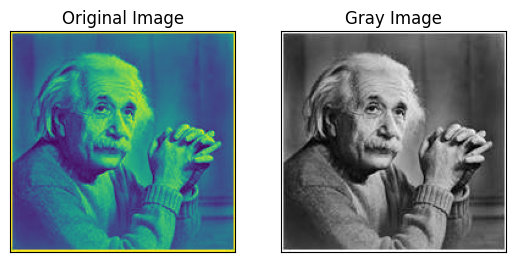

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('./img/einstein.jpg',0)
plt.subplot(121),plt.imshow(img)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img,cmap = 'gray')
plt.title('Gray Image'), plt.xticks([]), plt.yticks([])
plt.show()

## 2. Write a program to generate Histogram for different gray images

C:\Users\kusha\AppData\Local\Temp\ipykernel_44348\3542224724.py:6: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(),256,[0,256])


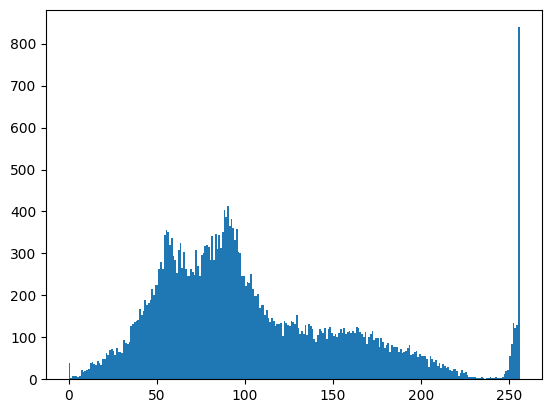

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('./img/einstein.jpg',0)
plt.hist(img.ravel(),256,[0,256])
plt.show()

## 3. Write a program to equalize a Histogram for an images

C:\Users\kusha\AppData\Local\Temp\ipykernel_44348\1552409104.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


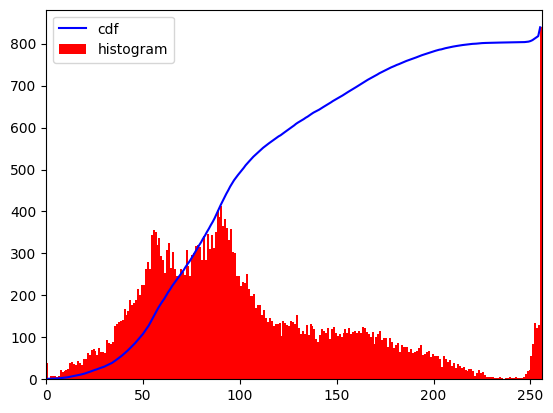

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('./img/einstein.jpg',0)

hist,bins = np.histogram(img.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max()/ cdf.max()

plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()